In [1]:
!pip install transformers torchvision pillow scikit-learn -q


In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.model_selection import train_test_split
import numpy as np
from PIL import Image
import requests
from io import BytesIO
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cpu


In [4]:
ads = pd.read_csv('ads_enriched.csv')
events = pd.read_csv('ad_events.csv')
campaigns = pd.read_csv('campaigns.csv')
users = pd.read_csv('users.csv')

In [5]:
#building engagement score again
weights = {'Impression ': 0, 'Click': 1,'Like': 2,'Comment': 3,'Share': 4,'Purchase': 5}
events['engagement_weight'] = events['event_type'].map(weights)

engagement = (
    events.groupby(['ad_id','user_id'])['engagement_weight'].sum()
    .reset_index().rename(columns = { 'engagement_weight': 'engagement_score' })
)

print(f"Total pairs: {len(engagement):,}")
print(engagement['engagement_score'].value_counts().head())

Total pairs: 50,332
engagement_score
0.0    42733
1.0     5036
2.0     1534
3.0      519
4.0      259
Name: count, dtype: int64


In [6]:
#merging and filtering

df = engagement.merge(ads, on='ad_id')
df = df.merge(campaigns[['campaign_id', 'total_budget', 'duration_days']], on='campaign_id')
df = df.merge(users[['user_id', 'user_age', 'user_gender']], on = 'user_id')
df = df[df['engagement_score']>0].copy().reset_index(drop=True)

print(f"Engaged rows: {len(df):,}")
print(f"Score range: {df['engagement_score'].min()} - {df['engagement_score'].max()}")

Engaged rows: 7,683
Score range: 1.0 - 8.0


Sample shape: (2000, 17)
Y range: 0.693 to 1.946


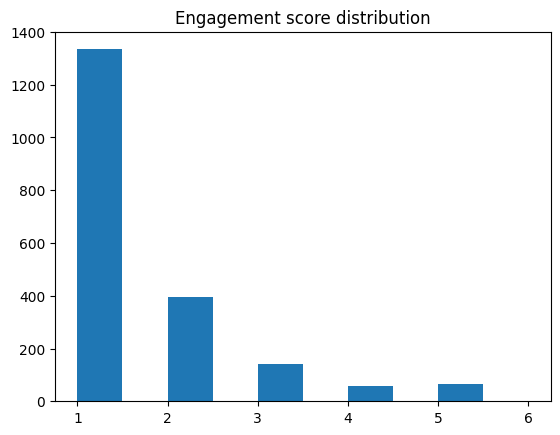

In [7]:
df_sample = df.sample(n=2000, random_state = 42).reset_index(drop=True)

y_tensor = torch.FloatTensor(
    np.log1p(df_sample['engagement_score'].values).reshape(-1,1)
)

print(f"Sample shape: {df_sample.shape}")
print(f"Y range: {y_tensor.min():.3f} to {y_tensor.max():.3f}")

plt.hist(df_sample['engagement_score'], bins = 10)
plt.title("Engagement score distribution")
plt.show()

In [8]:
#image embedder

class ImageEmbedder(nn.Module):
  def __init__(self):
    super().__init__()

    resnet = models.resnet50(pretrained = True)
    for param in resnet.parameters():
      param.requires_grad = False

    self.backbone = nn.Sequential(*list(resnet.children())[:-1])
    self.embedding_head = nn.Sequential(
        nn.Flatten(),
        nn.Linear(2048, 512),
        nn.ReLU()
    )

    def forward(self, x):
      return self.embedding_head(self.backbone(x))

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

image_embedder = ImageEmbedder().to(device)
image_embedder.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 130MB/s]


ImageEmbedder(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv

In [9]:
#embedding the images

from tqdm.auto import tqdm

url_cache = {}

def embed_image_url(url):
  if url in url_cache:
    return url_cache[url]

  try:
    img = Image.open(BytesIO(requests.get(url, timeout = 10).content)).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
      emb = image_embedder(tensor).squeeze(0).cpu()
    url_cache[url] = emb
    return emb

  except Exception as e:
    print(f"Failed: {e}")
    return torch.zeros(512)

image_embeddings = torch.stack([
  embed_image_url(url) for url in tqdm(df_sample['image_url'])
])

print(f"Image Embeddings: {image_embeddings.shape}")


  0%|          | 0/2000 [00:00<?, ?it/s]

Failed: Module [ImageEmbedder] is missing the required "forward" function
Failed: Module [ImageEmbedder] is missing the required "forward" function
Failed: Module [ImageEmbedder] is missing the required "forward" function
Failed: Module [ImageEmbedder] is missing the required "forward" function
Failed: Module [ImageEmbedder] is missing the required "forward" function
Failed: Module [ImageEmbedder] is missing the required "forward" function
Failed: Module [ImageEmbedder] is missing the required "forward" function
Failed: Module [ImageEmbedder] is missing the required "forward" function
Failed: Module [ImageEmbedder] is missing the required "forward" function
Failed: Module [ImageEmbedder] is missing the required "forward" function
Failed: Module [ImageEmbedder] is missing the required "forward" function
Failed: Module [ImageEmbedder] is missing the required "forward" function
Failed: Module [ImageEmbedder] is missing the required "forward" function
Failed: Module [ImageEmbedder] is miss

In [10]:
class TextEmbedder(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        for param in self.bert.parameters():
            param.requires_grad = False
        self.embedding_head = nn.Sequential(
            nn.Linear(768, 768),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
    def forward(self, input_ids, attention_mask):
        cls = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:,0,:]
        return self.embedding_head(cls)

tokenizer     = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
text_embedder = TextEmbedder().to(device)
text_embedder.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TextEmbedder(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linear(in

In [11]:
BATCH_SIZE = 32
texts = df_sample['ad_copy'].tolist()
all_text_embs = []

for i in tqdm(range(0, len(texts), BATCH_SIZE)):
  tokens = tokenizer(
      texts[i: i+BATCH_SIZE],
      return_tensors = 'pt',
      max_length = 128,
      padding = 'max_length',
      truncation = True
  )

  with torch.no_grad():
    emb = text_embedder(
        tokens['input_ids'].to(device),
        tokens['attention_mask'].to(device)
    ).cpu()

  all_text_embs.append(emb)

text_embeddings = torch.cat(all_text_embs, dim=0)

  0%|          | 0/63 [00:00<?, ?it/s]

In [12]:
indices = list(range(2000))

train_idx, test_idx = train_test_split(indices, test_size = 0.2, random_state = 42)

x_img_train = image_embeddings[train_idx]
x_text_train = text_embeddings[train_idx]
x_img_test = image_embeddings[test_idx]
x_text_test = text_embeddings[test_idx]
y_train = y_tensor[train_idx]
y_test = y_tensor[test_idx]

print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")

Train: 1600 | Test: 400


In [13]:
#fusion model

class FusionScorer(nn.Module):
  def __init__(self):
    super().__init__()

    self.fusion = nn.Sequential(
        nn.Linear(1280,512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512,256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 1)
    )

  def forward(self, img_emb, text_emb):
    return self.fusion(torch.cat([img_emb, text_emb], dim = 1))

fusion_model = FusionScorer().to(device)
trainable = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

Trainable parameters: 787,457


In [15]:
loss_fn   = nn.MSELoss()
optimizer = torch.optim.Adam(fusion_model.parameters(), lr=1e-4)

x_img_train_d  = x_img_train.to(device)
x_text_train_d = x_text_train.to(device)
y_train_d      = y_train.to(device)
x_img_test_d   = x_img_test.to(device)
x_text_test_d  = x_text_test.to(device)
y_test_d       = y_test.to(device)

train_losses, test_losses = [], []

for epoch in range(100):
    fusion_model.train()
    preds = fusion_model(x_img_train_d, x_text_train_d)
    loss  = loss_fn(preds, y_train_d)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    fusion_model.eval()
    with torch.no_grad():
        test_loss = loss_fn(fusion_model(x_img_test_d, x_text_test_d), y_test_d)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | Train: {loss.item():.4f} | Test: {test_loss.item():.4f}')

Epoch   0 | Train: 0.8375 | Test: 0.8086
Epoch  10 | Train: 0.5301 | Test: 0.4980
Epoch  20 | Train: 0.2182 | Test: 0.1936
Epoch  30 | Train: 0.1060 | Test: 0.1088
Epoch  40 | Train: 0.1174 | Test: 0.1108
Epoch  50 | Train: 0.1018 | Test: 0.1029
Epoch  60 | Train: 0.1032 | Test: 0.1030
Epoch  70 | Train: 0.1022 | Test: 0.1009
Epoch  80 | Train: 0.0995 | Test: 0.1009
Epoch  90 | Train: 0.1005 | Test: 0.1011


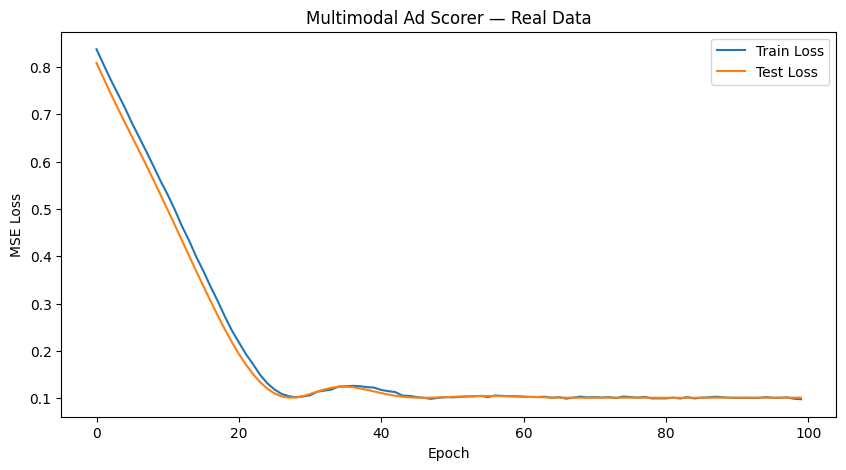

Final Train: 0.0978 | Final Test: 0.1010
Improvement: 88.3%


In [16]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses,  label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Multimodal Ad Scorer — Real Data')
plt.legend()
plt.show()

print(f'Final Train: {train_losses[-1]:.4f} | Final Test: {test_losses[-1]:.4f}')
print(f'Improvement: {(1 - train_losses[-1]/train_losses[0])*100:.1f}%')

In [17]:
torch.save({
    'fusion_model':     fusion_model.state_dict(),
    'image_embedder':   image_embedder.state_dict(),
    'text_embedder':    text_embedder.state_dict(),
    'final_train_loss': train_losses[-1],
    'final_test_loss':  test_losses[-1],
}, 'multimodal_ad_scorer.pt')

print('Saved: multimodal_ad_scorer.pt')

Saved: multimodal_ad_scorer.pt
